# 0 IMPORTAR LIBRERÍAS NECESARIAS

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image

# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
# Obtener lista de todas las rutas de las imágenes
image_paths = glob.glob("../data/raw/train/*.jpg") 
""" 1- glob.glob() es como un buscador de archivos
"   2- ../data/raw/train/*.jpg" le dice dónde buscar:  
    3- .. = sube una carpeta (desde src/)
    4- train = entra a esta carpeta
    5- *.jpg = busca TODOS los archivos que terminen en .jpg (el * significa "cualquier nombre")
    6- Guarda todas las rutas de las imágenes encontradas en la variable image_paths"""

print(f"Total de imágenes encontradas: {len(image_paths)}")

# Mostrar algunas rutas de ejemplo
print("\nEjemplos de rutas:")
for path in image_paths[:5]:
    print(path)

Total de imágenes encontradas: 25000

Ejemplos de rutas:
../data/raw/train\cat.0.jpg
../data/raw/train\cat.1.jpg
../data/raw/train\cat.10.jpg
../data/raw/train\cat.100.jpg
../data/raw/train\cat.1000.jpg


# 2 EXPLORAR UNA IMAGEN
Antes de entrenar, veamos cómo se ve una imagen y sus características

Imagen seleccionada: ../data/raw/train\cat.0.jpg
Tipo de dato: <class 'PIL.JpegImagePlugin.JpegImageFile'>


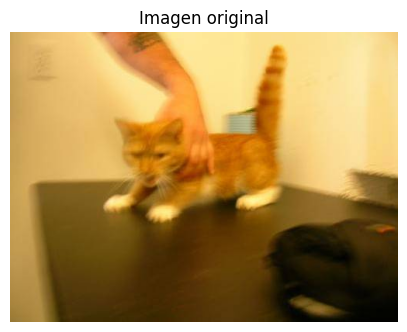

Tamaño de la imagen: (500, 374)


In [3]:
# Cargar UNA imagen de ejemplo
img_path = image_paths[0]  # Tomamos la primera imagen
print(f"Imagen seleccionada: {img_path}")

# Cargar la imagen
img = image.load_img(img_path)  # Carga la imagen
print(f"Tipo de dato: {type(img)}")

# Mostrar la imagen
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')  # Quita los ejes
plt.show()

# Ver las dimensiones (tamaño) de la imagen
print(f"Tamaño de la imagen: {img.size}")  # (ancho, alto)

# 3 CONVERTIR IMAGEN A NÚMEROS
Las computadoras solo entienden números. Convertimos la imagen a una matriz de números (array)

In [4]:
# Convertir imagen a array (matriz de números)
img_array = image.img_to_array(img)
print(f"Forma del array: {img_array.shape}")  # (alto, ancho, canales de color)
print(f"Rango de valores: {img_array.min()} a {img_array.max()}") # Los colores se forman mezclando 3 colores básicos: Rojo (R), Verde (G), Azul (B). Cada color tiene un valor de 0 a 255

# Ejemplo: ver los primeros valores
print(f"\nPrimeros valores del pixel superior izquierdo:")
print(img_array[0, 0])  # RGB: [Rojo, Verde, Azul]

Forma del array: (374, 500, 3)
Rango de valores: 0.0 a 255.0

Primeros valores del pixel superior izquierdo:
[203. 164.  87.]


# 4 PREPARAR TODAS LAS IMÁGENES
Cargar y preparar todas las imágenes para entrenar el modelo

In [5]:
# Definir tamaño estándar para todas las imágenes
IMG_SIZE = (150, 150)  # Todas las imágenes tendrán 150x150 pixels (debe coincidir con el modelo)

# Listas para guardar imágenes y etiquetas
images = []
labels = []

# IMPORTANTE: Usar solo un subconjunto de imágenes para no quedarse sin memoria
MAX_IMAGES = 25000  # Procesar solo 25000 imágenes.

print(f"Cargando máximo {MAX_IMAGES} imágenes...")
for i, img_path in enumerate(image_paths[:MAX_IMAGES]):
    # Cargar imagen con el tamaño definido
    img = image.load_img(img_path, target_size=IMG_SIZE)
    
    # Convertir a array
    img_array = image.img_to_array(img)
    
    # Normalizar: convertir valores de 0-255 a 0-1
    img_array = img_array / 255.0
    
    # Guardar
    images.append(img_array)
    
    # Extraer etiqueta del nombre del archivo
    # Ejemplo: si el archivo se llama "gato_001.jpg", la etiqueta sería "gato"
    label = os.path.basename(img_path).split('.')[0]
    labels.append(label)
    
    if (i + 1) % 200 == 0:
        print(f"Procesadas {i + 1} imágenes...")

print(f"\n✓ Total de imágenes procesadas: {len(images)}")
print(f"✓ Total de etiquetas: {len(labels)}")
print(f"✓ Categorías únicas: {set(labels)}")

Cargando máximo 25000 imágenes...
Procesadas 200 imágenes...
Procesadas 400 imágenes...
Procesadas 600 imágenes...
Procesadas 800 imágenes...
Procesadas 1000 imágenes...
Procesadas 1200 imágenes...
Procesadas 1400 imágenes...
Procesadas 1600 imágenes...
Procesadas 1800 imágenes...
Procesadas 2000 imágenes...
Procesadas 2200 imágenes...
Procesadas 2400 imágenes...
Procesadas 2600 imágenes...
Procesadas 2800 imágenes...
Procesadas 3000 imágenes...
Procesadas 3200 imágenes...
Procesadas 3400 imágenes...
Procesadas 3600 imágenes...
Procesadas 3800 imágenes...
Procesadas 4000 imágenes...
Procesadas 4200 imágenes...
Procesadas 4400 imágenes...
Procesadas 4600 imágenes...
Procesadas 4800 imágenes...
Procesadas 5000 imágenes...
Procesadas 5200 imágenes...
Procesadas 5400 imágenes...
Procesadas 5600 imágenes...
Procesadas 5800 imágenes...
Procesadas 6000 imágenes...
Procesadas 6200 imágenes...
Procesadas 6400 imágenes...
Procesadas 6600 imágenes...
Procesadas 6800 imágenes...
Procesadas 7000 im

# 5 CONVERTIR DATOS A FORMATO CORRECTO
Convertir listas a arrays de NumPy y preparar etiquetas

In [6]:
# Convertir listas a arrays de NumPy
X = np.array(images)  # X = datos (imágenes)
print(f"Forma de X: {X.shape}")  # (num_imágenes, alto, ancho, canales)

# Convertir etiquetas de texto a números
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)  # y = etiquetas (0, 1)
print(f"Forma de y: {y.shape}")
print(f"\nEjemplo de conversión:")
print(f"  {labels[0]} → {y[0]}")
print(f"  {labels[12501]} → {y[12501]}")

Forma de X: (25000, 150, 150, 3)
Forma de y: (25000,)

Ejemplo de conversión:
  cat → 0
  dog → 1


# 5.1 VERIFICAR ETIQUETAS
Comprobar que las etiquetas se extrajeron correctamente

In [7]:
# 1. Ver las primeras 5 y últimas 5 etiquetas
print("Primeras 5 etiquetas:")
for i in range(min(5, len(labels))):
    print(f"  {i}: {labels[i]}")

print("\nÚltimas 5 etiquetas:")
for i in range(max(0, len(labels) - 5), len(labels)):
    print(f"  {i}: {labels[i]}")

# 2. Contar cuántas imágenes hay de cada categoría
from collections import Counter
conteo = Counter(labels)
print(f"\n📊 Conteo por categoría:")
for categoria, cantidad in conteo.items():
    print(f"  {categoria}: {cantidad} imágenes")

# 3. Ver qué categorías únicas existen
print(f"\n🏷️ Categorías únicas encontradas: {sorted(set(labels))}")

# 4. Verificar algunas rutas y sus etiquetas
print(f"\n🔍 Verificación ruta → etiqueta (primeras 4):")
for i in range(min(4, len(image_paths))):
    filename = os.path.basename(image_paths[i])
    print(f"  {i}: {filename} → '{labels[i]}'")

# Verificar posiciones 12501-12504
print(f"\n🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):")
for i in range(12501, min(12505, len(image_paths))):
    if i < len(image_paths):
        filename = os.path.basename(image_paths[i])
        print(f"  {i}: {filename} → '{labels[i]}'")

Primeras 5 etiquetas:
  0: cat
  1: cat
  2: cat
  3: cat
  4: cat

Últimas 5 etiquetas:
  24995: dog
  24996: dog
  24997: dog
  24998: dog
  24999: dog

📊 Conteo por categoría:
  cat: 12500 imágenes
  dog: 12500 imágenes

🏷️ Categorías únicas encontradas: ['cat', 'dog']

🔍 Verificación ruta → etiqueta (primeras 4):
  0: cat.0.jpg → 'cat'
  1: cat.1.jpg → 'cat'
  2: cat.10.jpg → 'cat'
  3: cat.100.jpg → 'cat'

🔍 Verificación ruta → etiqueta (desde 12501 hasta 12504):
  12501: dog.1.jpg → 'dog'
  12502: dog.10.jpg → 'dog'
  12503: dog.100.jpg → 'dog'
  12504: dog.1000.jpg → 'dog'


# 6 DIVIDIR DATOS EN ENTRENAMIENTO Y PRUEBA
Separar datos: 80% para entrenar, 20% para probar

In [8]:
from sklearn.model_selection import train_test_split

# Dividir datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% para pruebas
    random_state=0  
)

print(f"Datos de entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de prueba: {X_test.shape[0]} imágenes")

Datos de entrenamiento: 20000 imágenes
Datos de prueba: 5000 imágenes


# 7 CREAR EL MODELO (Red Neuronal)

#### Construir una red neuronal simple para clasificar imágenes

### Analogía Completa

Es como aprender a cocinar:

Sequential + capas: Lees la receta completa (ingredientes y pasos)

compile: Preparas la cocina (prendes la estufa, sacas los utensilios, decides a qué temperatura cocinar)

fit: Empiezas a cocinar siguiendo los pasos con los ingredientes reales

No puedes saltarte pasos: No puedes entrenar sin compilar, ni compilar sin crear la arquitectura primero. Cada paso depende del anterior.

In [14]:
# MODELO PARA 25,000 IMÁGENES

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # Bloque 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    
    # Bloque 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Bloque 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Bloque 4
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Clasificador
    Flatten(),
    Dropout(0.5),  # Reduce overfitting
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,812,482 (25.99 MB)

 Trainable params: 6,812,482 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

# 8 COMPILAR EL MODELO
Configurar cómo el modelo aprenderá

In [15]:
# Compilar el modelo
model.compile(
    optimizer='adam',  # Algoritmo para ajustar pesos
    loss='sparse_categorical_crossentropy',  # Función de error
    metrics=['accuracy']  # Métrica para evaluar
)

print("✓ Modelo compilado y listo para entrenar")

✓ Modelo compilado y listo para entrenar


# 9 ENTRENAR EL MODELO
¡Aquí es donde la magia sucede! El modelo aprende de las imágenes

In [16]:
# Segunda división: del 80%, hacer 80% train y 20% validation
X_train_2, X_val, y_train_2, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=0  # 0.20 * 0.8 = 0.2 del total
)
print(f"Datos de entrenamiento finales: {X_train_2.shape[0]} imágenes")
print(f"Datos de validación: {X_val.shape[0]} imágenes")

Datos de entrenamiento finales: 16000 imágenes
Datos de validación: 4000 imágenes


In [17]:
# Entrenar el modelo
history = model.fit(
    X_train_2, y_train_2,  # Datos de entrenamiento
    epochs=6,  # Número de veces que verá todos los datos
    validation_data=(X_val, y_val),  # Datos para  varlidar validation_split = 0.2
    verbose=1  # Mostrar progreso
)

print("\n✓ Entrenamiento completado")

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 362ms/step - accuracy: 0.5553 - loss: 0.6850 - val_accuracy: 0.6310 - val_loss: 0.6533
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 358ms/step - accuracy: 0.6603 - loss: 0.6237 - val_accuracy: 0.7103 - val_loss: 0.5691
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 355ms/step - accuracy: 0.7313 - loss: 0.5438 - val_accuracy: 0.7203 - val_loss: 0.5588
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 313ms/step - accuracy: 0.7746 - loss: 0.4721 - val_accuracy: 0.7915 - val_loss: 0.4544
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 356ms/step - accuracy: 0.8109 - loss: 0.4146 - val_accuracy: 0.8033 - val_loss: 0.4233
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.8346 - loss: 0.3743 - val_accuracy: 0.8245 - val_loss: 0.3918

✓ Entrenamiento completado


CONCLUSIÓN: El modelo aprendió a distinguir entre gatos y perros con un 82-83% de precisión. De cada 100 imágenes, acierta aproximadamente 82-83.

# MODELO SUGERIDO EN LA PLATAFORMA (NO FUNCIONA)

In [12]:
# Entrenar el modelo
history = model.fit(
    X_train_2, y_train_2,  # Datos de entrenamiento
    epochs=6,  # Número de veces que verá todos los datos
    validation_data=(X_val, y_val),  # Datos para  varlidar validation_split = 0.2
    verbose=1  # Mostrar progreso
)

print("\n✓ Entrenamiento completado")

Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 2930s 6s/step - accuracy: 0.5046 - loss: 0.6943 - val_accuracy: 0.5025 - val_loss: 0.6932
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 2527s 5s/step - accuracy: 0.4994 - loss: 0.6932 - val_accuracy: 0.4975 - val_loss: 0.6932
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 2414s 5s/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.4975 - val_loss: 0.6932
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 2823s 6s/step - accuracy: 0.4963 - loss: 0.6932 - val_accuracy: 0.5025 - val_loss: 0.6931
Epoch 5/6
 55/500 ━━━━━━━━━━━━━━━━━━━━ 43:44 6s/step - accuracy: 0.4875 - loss: 0.6932

KeyboardInterrupt: 

# 10 VISUALIZAR EL APRENDIZAJE
Ver cómo mejoró el modelo durante el entrenamiento

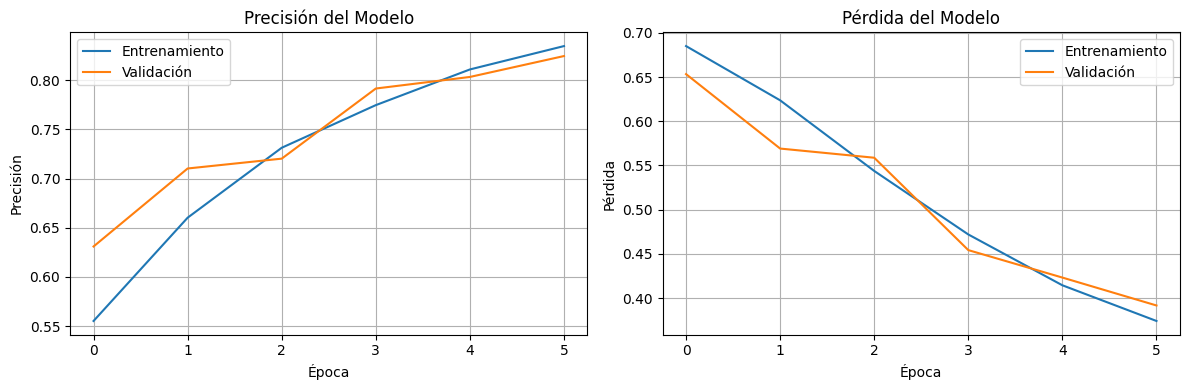

In [18]:
# Graficar la precisión
plt.figure(figsize=(12, 4))

# Gráfica 1: Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica 2: Pérdida (error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 11 EVALUAR EL MODELO
Verificar qué tan bien funciona el modelo con datos nuevos

In [19]:
# Evaluar en datos de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"📊 Resultados en datos de prueba:")
print(f"   Precisión: {test_accuracy * 100:.2f}%")
print(f"   Pérdida: {test_loss:.4f}")

📊 Resultados en datos de prueba:
   Precisión: 82.98%
   Pérdida: 0.3806


# 12 HACER PREDICCIONES
Usar el modelo para clasificar una imagen nueva

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


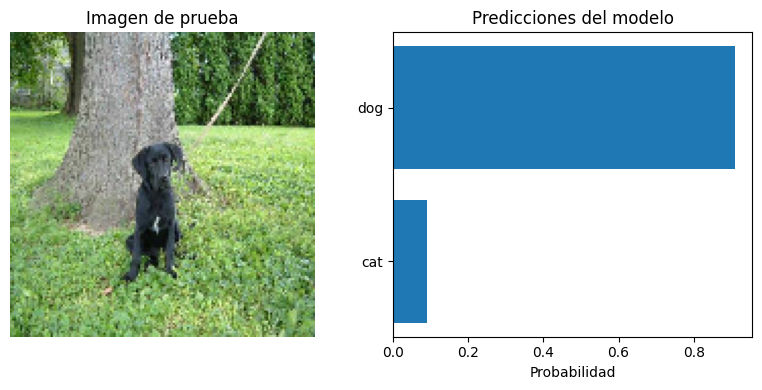


🎯 Predicción:
   Clase real: dog
   Clase predicha: dog
   Confianza: 91.07%


In [20]:
# Seleccionar una imagen de prueba
test_index = 0
test_image = X_test[test_index]
true_label = y_test[test_index]

# Hacer predicción (necesita dimensión extra)
prediction = model.predict(test_image.reshape(1, 150, 150, 3))
predicted_class = np.argmax(prediction)  # Clase con mayor probabilidad

# Visualizar resultado
plt.figure(figsize=(8, 4))

# Imagen
plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title(f"Imagen de prueba")
plt.axis('off')

# Probabilidades
plt.subplot(1, 2, 2)
classes = label_encoder.classes_
plt.barh(classes, prediction[0])
plt.xlabel('Probabilidad')
plt.title('Predicciones del modelo')
plt.tight_layout()
plt.show()

# Resultado
print(f"\n🎯 Predicción:")
print(f"   Clase real: {label_encoder.inverse_transform([true_label])[0]}")
print(f"   Clase predicha: {label_encoder.inverse_transform([predicted_class])[0]}")
print(f"   Confianza: {prediction[0][predicted_class] * 100:.2f}%")

# 13 GUARDAR EL MODELO (OPCIONAL)
Guardar el modelo entrenado para usarlo después sin tener que entrenar de nuevo

In [21]:
# Guardar el modelo
model.save('../models/image_classifier.h5')
print("✓ Modelo guardado en: ../models/image_classifier.h5")

# Para cargar el modelo después:
# from keras.models import load_model
# model_loaded = load_model('../models/image_classifier.h5')

✓ Modelo guardado en: ../models/image_classifier.h5
